In [1]:
!pip install pandas
!pip install matplotlib

In [2]:
import pandas as pd

In [3]:
#series(1D labelled array)
s=pd.Series([1,2,3,4,5])
print(s)
print(s.index)
print(type(s))

0    1
1    2
2    3
3    4
4    5
dtype: int64
RangeIndex(start=0, stop=5, step=1)
<class 'pandas.Series'>


In [4]:
# named index concept->label (customised index)
s=pd.Series([23,24,25,26],index=["Adam","Eve","Bob","Charlie"])
print(s)
print(s["Adam"])
print(s.index)

Adam       23
Eve        24
Bob        25
Charlie    26
dtype: int64
23
Index(['Adam', 'Eve', 'Bob', 'Charlie'], dtype='str')


In [5]:
#DataFrame(2D labelled array)
# we can create DataFrame by 3 ways:-
# 1. using dictionary of list
# 2. using list of list
# 3. using numpy array

#1st way:-using dictionary of list

info={
    "Name":["Adam","Eve","Bob"],
    "Age":[23,24,25],
    "GPA":[9.5,8.6,7.2]
}

df=pd.DataFrame(info)
print(df,type(df))

print(df.index) # gives row labels
print(df.columns) # gives column labels


# 2 way:- using list of list

df=pd.DataFrame([["Adam",23],["Eve",25],["Bob",26]],columns=["Name","Age"])
print(df)

# 3 way:- using numpy array

import numpy as np

np_arr=np.array([[1,2,3],[4,5,6]])
df=pd.DataFrame(np_arr,columns=["A","B","C"])
print(df)

   Name  Age  GPA
0  Adam   23  9.5
1   Eve   24  8.6
2   Bob   25  7.2 <class 'pandas.DataFrame'>
RangeIndex(start=0, stop=3, step=1)
Index(['Name', 'Age', 'GPA'], dtype='str')
   Name  Age
0  Adam   23
1   Eve   25
2   Bob   26
   A  B  C
0  1  2  3
1  4  5  6


In [6]:
# working with csv and json files
#pd.read_csv(filename), pd.read_json(filename)
df=pd.read_csv("employee_data.csv")
print(df)
print(type(df))

   ID     Name  Age Department  Salary
0   1    Alice   25         HR   55000
1   2      Bob   32         IT   72000
2   3  Charlie   28    Finance   48000
3   4    David   45  Marketing   91000
4   5      Eva   38         IT   65000
5   6    Frank   29    Finance   50000
6   7    Grace   41         HR   82000
7   8   Hannah   26  Marketing   47000
8   9      Ian   35         IT   75000
9  10    Julia   30    Finance   60000
<class 'pandas.DataFrame'>


In [7]:
# DataFrame Methods

df.head() # starting 5 rows by default
df.tail(2)
df.sample(3) # random rows from data

df.info()
df.describe() # statistical computation of numerical columns

df.shape # (row,column)
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   ID          10 non-null     int64
 1   Name        10 non-null     str  
 2   Age         10 non-null     int64
 3   Department  10 non-null     str  
 4   Salary      10 non-null     int64
dtypes: int64(3), str(2)
memory usage: 532.0 bytes


ID            10
Name          10
Age           10
Department     4
Salary        10
dtype: int64

In [8]:
# working with kaggle dataset
# AQI Dataset

df=pd.read_csv("globalAirQuality.csv")
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


In [9]:
#selecting data column-wise

df["city"]         # to access a single column
df[["city","aqi"]] # to acces multiple columns

#selecting data row-wise

df.loc[2]
df.loc[0:2] #start idx:end idx(inclusive)

df.iloc[2]
df.iloc[0:2] #start idx:end idx(exclusive)

#selecting specific cells(row,column)

df.loc[0:2,"city"]
#df.iloc[0:2,"city"] # gives error as iloc can take numeric idx only here
df.iloc[0:2,2]

# access scalar values

df.at[0,"city"]
df.iat[0,2]  # iat based indexing can only have integer indexers

'New York'

In [10]:
# all these above method to access row and columns return view 
# and if you make changes in these view they will be reflected back in  original data

cities=df["city"] #return a view
cities[0]="Mumbai"
df #data manipulated here
cities[0]="New York"

# so to avoid such mistake we always use copy() method 
cities=df["city"].copy() #return a copy
cities[0]="Mumbai"
cities
df # no changes on original data

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2025-11-19 13:25:17.554219,CH,Zurich,47.377,8.542,27.899,74.179,41.474,6.677,50.869,1.028,103,7.079,52.443,7.452
17996,2025-11-19 14:25:17.554219,CH,Zurich,47.377,8.542,2.950,47.988,42.235,2.821,35.551,0.644,105,28.734,85.678,4.496
17997,2025-11-19 15:25:17.554219,CH,Zurich,47.377,8.542,61.347,72.908,46.976,5.763,66.492,0.947,122,21.951,72.311,9.660
17998,2025-11-19 16:25:17.554219,CH,Zurich,47.377,8.542,40.722,95.152,32.957,5.524,53.193,0.868,95,24.042,31.880,2.642


In [11]:
df

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2025-11-19 13:25:17.554219,CH,Zurich,47.377,8.542,27.899,74.179,41.474,6.677,50.869,1.028,103,7.079,52.443,7.452
17996,2025-11-19 14:25:17.554219,CH,Zurich,47.377,8.542,2.950,47.988,42.235,2.821,35.551,0.644,105,28.734,85.678,4.496
17997,2025-11-19 15:25:17.554219,CH,Zurich,47.377,8.542,61.347,72.908,46.976,5.763,66.492,0.947,122,21.951,72.311,9.660
17998,2025-11-19 16:25:17.554219,CH,Zurich,47.377,8.542,40.722,95.152,32.957,5.524,53.193,0.868,95,24.042,31.880,2.642


In [12]:
#Filtering Data
# Method 1:- using []

df[df["aqi"]>100] # single filtering condition

df[(df["aqi"]>100) & (df["temperature"]>30)] # multiple filtering condition
df[(df["aqi"]>100) & (df["temperature"]<30)] 

aqi_data=df[(df["aqi"]>100) & (df["temperature"]>30)][["city","aqi"]]
aqi_data

# after filtering row label are preserved

aqi_data.iloc[0]
#aqi_data.loc[0] # gives error, here you need to give specific labe as its not idx 
aqi_data.loc[6]

# Method 2:- using query (much easier way of filtering)
# query returns a copy not view
#no need of remembering when it returns a view or copy when need copy use copy() method then only makes changes in data

df.query("aqi>100")
df.query("aqi>100 & temperature >30")
df.query("aqi>100 & temperature >30")[["city","aqi"]]

# we can use variables to pass condition using syntax-> @variable_name

aqi_var=100
df.query("aqi>@aqi_var")

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
6,2025-11-05 00:25:17.554219,US,New York,40.713,-74.006,77.690,65.198,20.302,7.641,62.687,0.734,155,36.729,47.651,4.542
7,2025-11-05 01:25:17.554219,US,New York,40.713,-74.006,57.816,111.709,34.533,6.945,41.304,0.771,115,37.891,53.314,7.605
8,2025-11-05 02:25:17.554219,US,New York,40.713,-74.006,60.914,44.775,40.936,6.779,36.751,1.014,121,24.092,48.148,8.686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17991,2025-11-19 09:25:17.554219,CH,Zurich,47.377,8.542,52.120,71.160,35.405,7.752,39.811,0.878,104,32.556,31.372,2.787
17993,2025-11-19 11:25:17.554219,CH,Zurich,47.377,8.542,76.613,37.495,29.662,5.419,57.042,1.103,153,20.437,79.602,2.663
17995,2025-11-19 13:25:17.554219,CH,Zurich,47.377,8.542,27.899,74.179,41.474,6.677,50.869,1.028,103,7.079,52.443,7.452
17996,2025-11-19 14:25:17.554219,CH,Zurich,47.377,8.542,2.950,47.988,42.235,2.821,35.551,0.644,105,28.734,85.678,4.496


In [13]:
# Data Cleaning

# 1.Handling Missing Values

df=pd.read_csv("raw_data.csv")

df.isnull()

df.isnull().sum()

df.dropna() # rows drop
df.dropna(axis=1) # columns drop

df.fillna(0)
df["age"].fillna(0)

#fill missing ages with mean of age
cleaned_data=df.copy()
age_mean=cleaned_data["age"].mean()
cleaned_data["age"]=cleaned_data["age"].fillna(age_mean)
cleaned_data

df.ffill()
df.bfill()

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,34.0,Canada,Female,62000.0
3,3,Alex,34.0,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,51000.0
5,5,Li Wei,27.0,China,Male,51000.0
6,6,Ahmed Khan,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,USA,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,31.0,Mexico,Male,45000.0


In [14]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [15]:
# 2. Handle Duplicates Values

df.duplicated()

df.drop_duplicates() # row label preserved here to 
df # changes are not reflected in original data so either make a copy() or use inplace attribute
df2=df.copy()
df.drop_duplicates(inplace=True)
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0
10,10,Emily Davis,31.0,USA,NaN,58000.0


In [16]:
df=df2

In [17]:
df

,id,name,age,country,gender,income
0,1,John Doe,29.0,USA,Male,55000.0
1,1,John Doe,29.0,USA,Male,55000.0
2,2,Jane Smith,NaN,Canada,Female,62000.0
3,3,Alex,NaN,USA,Unknown,47000.0
4,4,Maria Garcia,34.0,Spain,Female,NaN
5,5,Li Wei,27.0,China,Male,51000.0
6,6,NaN,45.0,India,Female,73000.0
7,7,Ahmed Khan,38.0,NaN,Male,68000.0
8,8,Rachel Lee,29.0,USA,Female,62000.0
9,9,Carlos Ruiz,NaN,Mexico,Male,45000.0


In [18]:
# 3. Handle Data Types & date-time

df.dtypes

df2=df.copy()

df2=df2.fillna(0)
df2["age"]=df2["age"].astype("int64").copy()
df2.dtypes

date_str="2026-12-31"
type(date_str)
date_str=pd.Series([pd.to_datetime("2026-12-31")])
type(date_str.dtypes)


numpy.dtypes.DateTime64DType

In [19]:
# 4. Handle Strings

df["gender"].str.lower()
df["gender"].str.upper()
df["gender"].str.capitalize()

# str.split(" ")

df["name"].str.split(" ")

df["country"].str.contains("US")
df["country"].str.contains("india",case=False)

0     False
1     False
2     False
3     False
4     False
5     False
6      True
7     False
8     False
9     False
10    False
Name: country, dtype: bool

In [20]:
# Feature Engineering (Transforming Data )
# apply() ,map(),assign(),replace(old,new)

df2=df.copy()

df2["tax"]=df2["income"].apply(lambda x: "20%" if x>=60000 else "10%")

gender_map={"Male":"M","Female":"F","Unknown":"U"}
df2["gender"]=df2["gender"].map(gender_map)

df2=df2.assign(new_income=df2["income"]*1.1)
df2

df2["country"]=df2["country"].replace("USA","United States")
df2

#Transforming Data
# rename()
df2.columns=["Id","Name","Age","Country","Gender","Income","Tax","New_Income"]
df2.rename(columns={"Income":"Salary"})
df2.rename(index={1:"First"})

#sort_values()
df2.sort_values("Income")
df2.fillna(50)
df2.sort_values(["Income","Age"])
sorted_df=df2.sort_values("Income",ascending=False)

df2.sort_index()
df2.sort_index(ascending=False)

#reset()
sorted_df.reset_index()
sorted_df.reset_index(drop=True)

#ranking

sorted_df["Ranking"]=sorted_df["Income"].rank()
sorted_df["Ranking"]=sorted_df["Income"].rank(ascending=False)
sorted_df["Ranking"]=sorted_df["Income"].rank(method="dense")
sorted_df["Ranking"]=sorted_df["Income"].rank(method="min")
sorted_df["Ranking"]=sorted_df["Income"].rank(method="max")
sorted_df

#reorder
sorted_df[["Id","Name","Age","Country","Gender","Income","New_Income","Tax"]]

,Id,Name,Age,Country,Gender,Income,New_Income,Tax
6,6,NaN,45.0,India,F,73000.0,80300.0,20%
7,7,Ahmed Khan,38.0,NaN,M,68000.0,74800.0,20%
8,8,Rachel Lee,29.0,United States,F,62000.0,68200.0,20%
2,2,Jane Smith,NaN,Canada,F,62000.0,68200.0,20%
10,10,Emily Davis,31.0,United States,NaN,58000.0,63800.0,10%
0,1,John Doe,29.0,United States,M,55000.0,60500.0,10%
1,1,John Doe,29.0,United States,M,55000.0,60500.0,10%
5,5,Li Wei,27.0,China,M,51000.0,56100.0,10%
3,3,Alex,NaN,United States,U,47000.0,51700.0,10%
9,9,Carlos Ruiz,NaN,Mexico,M,45000.0,49500.0,10%


In [21]:
# Task->Shift id column to end
df3=df.copy()

new_col_order=[col for col in df3.columns if col!="id"]+["id"]
print(new_col_order)
df3[new_col_order]

['name', 'age', 'country', 'gender', 'income', 'id']


,name,age,country,gender,income,id
0,John Doe,29.0,USA,Male,55000.0,1
1,John Doe,29.0,USA,Male,55000.0,1
2,Jane Smith,NaN,Canada,Female,62000.0,2
3,Alex,NaN,USA,Unknown,47000.0,3
4,Maria Garcia,34.0,Spain,Female,NaN,4
5,Li Wei,27.0,China,Male,51000.0,5
6,NaN,45.0,India,Female,73000.0,6
7,Ahmed Khan,38.0,NaN,Male,68000.0,7
8,Rachel Lee,29.0,USA,Female,62000.0,8
9,Carlos Ruiz,NaN,Mexico,Male,45000.0,9


In [22]:
# Writing Data to CSV
# before writing to some csv file remove duplicate rows, handle missing values and sort on the basis of income

df3=df.copy()

df3=df3.drop_duplicates()
df3=df3.fillna(0)
df3=df3.sort_values("income")

df3=df3.reset_index(drop=True)

df3.to_csv("sorted_data.csv")

In [23]:
# Grouping & Aggregation of Data
# groupby()
# mean/sum/max/min/count etc.
# agg()


df.groupby("country")["income"].mean()
df.groupby("country")["income"].min()
df.groupby("country")["income"].max()

# when we want to to apply multiple aggregate func on same column or want different aggregate func on different columns
# use agg()
df.groupby("country")["income"].agg(["mean","min","max"])
df.groupby("country")["income"].aggregate(["mean","min","max"])
df.groupby("country")["income"].agg(avg_salary="mean",min_salary="min",max_salary="max")

df.groupby("country").agg({
    "income":"mean",
    "age":"min"
})
df.groupby("country").agg(
    max_salary=("income","mean"),
    min_age=("age","min")
)

,max_salary,min_age
country,,
Canada,62000.0,NaN
China,51000.0,27.0
India,73000.0,45.0
Mexico,45000.0,NaN
Spain,NaN,34.0
USA,55400.0,29.0


In [24]:
# Melt & Pivot 
# Melt-Wide to Long Format
# Pivot-Long to Wide Format

df=pd.DataFrame({
    "country":["USA","USA","India","India"],
    "year":[2020,2021,2020,2021],
    "sales":[100,20,90,110],
    "profit":[20,25,18,22]
})

melted_df=df.melt(
    id_vars=["country","year"],
    value_vars=["sales","profit"],
    var_name="metrics",
    value_name="value"
)

pivot_df=melted_df.pivot(
    index=["country","year"],
    columns="metrics",
    values="value"
)

<Axes: xlabel='Age', ylabel='Salary'>

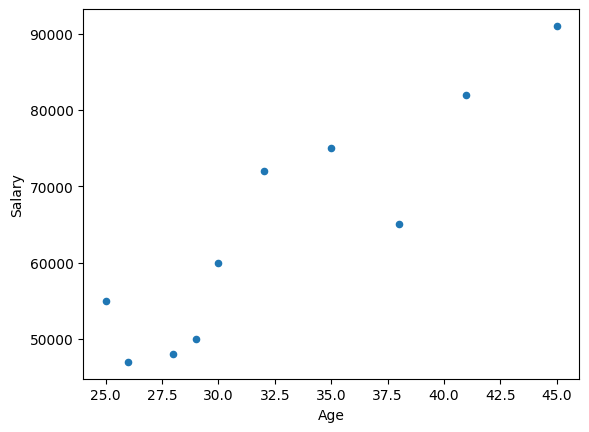

In [26]:
# Basic Visualisation in Pandas
# hist()
# plot()


df=pd.read_csv("employee_data.csv")

#df["Age"].hist()

df.plot(kind="scatter",x="Age",y="Salary")

In [36]:
# Merging & Joining Data
# inner join
# left join 
# right join 
# outer join 

df_customers=pd.DataFrame({
    "name":["Adam","Bob","Charlie","Dave"],
    "customer_id":[1,2,3,4]
})


df_orders=pd.DataFrame({
    "order_id":[101,102,103,104],
    "customer_id":[2,1,4,5],
    "amount":[250,120,300,180]
})

pd.merge(df_customers,df_orders,on="customer_id") # inner join 
pd.merge(df_customers,df_orders,on="customer_id",how="left") # left join 
pd.merge(df_customers,df_orders,on="customer_id",how="right") # right join 
pd.merge(df_customers,df_orders,on="customer_id",how="outer") # outer join 

,name,customer_id,order_id,amount
0,Adam,1,102.0,120.0
1,Bob,2,101.0,250.0
2,Charlie,3,NaN,NaN
3,Dave,4,103.0,300.0
4,NaN,5,104.0,180.0


In [42]:
# Data Concatenation
# Stacking DataFrames on top of each other (rows) or side by side (columns).

df1=pd.DataFrame({
    "id":[1,2,3],
    "name":["Adam","Eve","Bob"]
})


df2=pd.DataFrame({
    "id":[4,5,6],
    "name":["Charlie","Fester","Gilian"]
})

pd.concat([df1,df2]) # row concatenation
pd.concat([df1,df2],ignore_index=True) # here row labels are not preserved
pd.concat([df1,df2],axis=1) #  concatenation

,id,name,id,name
0,1,Adam,4,Charlie
1,2,Eve,5,Fester
2,3,Bob,6,Gilian
